# Kalman Filter — Kansen & Betting Simulatie vs Polymarket
Converteert Kalman xG voorspellingen naar win/gelijk/verlies kansen via Poisson,
en simuleert €1 inzet per wedstrijd tegen Polymarket odds.

In [41]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Stap 1 — Data laden

In [42]:
import os
os.chdir(r'C:\Users\semwi\FPL-Core-Insights\data')

import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

kalman = pd.read_csv(r'Kalman data\kalman_expected_goals.csv')
kalman['date'] = pd.to_datetime(kalman['date'])

poly = pd.read_csv('polymarket_snapshots.csv')
poly['kickoff'] = pd.to_datetime(poly['kickoff'])
poly = poly[poly['prob_home'].notna() & (poly['prob_home'] != '')].copy()
poly['prob_home'] = poly['prob_home'].astype(float)
poly['prob_away'] = poly['prob_away'].astype(float)
poly['prob_draw'] = poly['prob_draw'].astype(float)

print(f'Kalman wedstrijden:     {len(kalman)}')
print(f'Polymarket wedstrijden: {len(poly)}')
poly[['home_team','away_team','kickoff','prob_home','prob_draw','prob_away']].head()

Kalman wedstrijden:     2608
Polymarket wedstrijden: 675


,home_team,away_team,kickoff,prob_home,prob_draw,prob_away
0,Manchester United,Fulham,2024-08-16 19:00:00,0.605,0.225,0.185
1,Ipswich Town,Liverpool,2024-08-17 11:30:00,0.105,0.170,0.745
2,Arsenal,Wolverhampton,2024-08-17 14:00:00,0.855,0.115,0.070
3,Brentford,Crystal Palace,2024-08-18 13:00:00,0.365,0.285,0.350
4,Fulham,Leicester City,2024-08-24 14:00:00,0.525,0.270,0.225


## Stap 2 — Kansen berekenen via Poisson
We gebruiken `kalman_xg_pred_home` en `kalman_xg_pred_away` als λ voor een Poisson verdeling.
Door alle scorecombinaties (0-0 t/m 8-8) op te tellen krijgen we P(thuis wint), P(gelijk), P(uit wint).

In [43]:
def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    """Correctie voor lage scores — vermindert gelijkspel overschatting."""
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    """
    Verbeterde versie met:
    1. Lambda scaling — Kalman onderschat xG systematisch (1.595 vs 1.679 werkelijk)
       Schaal omhoog met de verhouding werkelijk/voorspeld
    2. Dixon-Coles correctie voor lage scores
    """
    # Scaling factor gebaseerd op geobserveerde bias
    # Werkelijk: home=1.679, away=1.438 | Kalman: home=1.595, away=1.327
    SCALE_HOME = 1.679 / 1.595  # = 1.053
    SCALE_AWAY = 1.438 / 1.327  # = 1.084

    lambda_home = max(lambda_home * SCALE_HOME, 0.05)
    lambda_away = max(lambda_away * SCALE_AWAY, 0.05)

    prob_home = 0.0
    prob_draw = 0.0
    prob_away = 0.0

    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p

    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# Vergelijk oud vs nieuw
print('Zonder correctie → Met correctie:')
for lh, la in [(1.8, 1.2), (1.5, 1.0), (1.2, 0.8), (0.3, 0.15)]:
    ph_oud = poisson.pmf
    ph, pd_, pa = xg_to_probabilities(lh, la)
    print(f'xG {lh:.1f} vs {la:.1f} → H:{ph:.3f} D:{pd_:.3f} A:{pa:.3f}')

Zonder correctie → Met correctie:
xG 1.8 vs 1.2 → H:0.500 D:0.250 A:0.250
xG 1.5 vs 1.0 → H:0.473 D:0.282 A:0.245
xG 1.2 vs 0.8 → H:0.439 D:0.323 A:0.238
xG 0.3 vs 0.1 → H:0.232 D:0.660 A:0.108


## Stap 3 — Kansen berekenen voor alle wedstrijden met Kalman features

In [44]:
# Alleen wedstrijden met Kalman features
kalman_valid = kalman[kalman['kalman_xg_pred_home'].notna()].copy()

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(row['kalman_xg_pred_home'], row['kalman_xg_pred_away']),
    axis=1
)

kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]

print(f'Kansen berekend voor {len(kalman_valid)} wedstrijden')
kalman_valid[['home_team','away_team','kalman_xg_pred_home','kalman_xg_pred_away',
              'kalman_prob_home','kalman_prob_draw','kalman_prob_away']].head(8)

Kansen berekend voor 2608 wedstrijden


,home_team,away_team,kalman_xg_pred_home,kalman_xg_pred_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Liverpool,Norwich City,1.4336,0.8447,0.495198,0.291921,0.212881
1,West Ham United,Manchester City,0.9635,1.2568,0.262593,0.306350,0.431057
2,Bournemouth,Sheffield United,1.6802,0.7207,0.595025,0.257573,0.147402
3,Burnley,Southampton,1.4540,0.8328,0.504125,0.289413,0.206463
4,Crystal Palace,Everton,1.1934,1.0147,0.381937,0.312648,0.305415
5,Watford,Brighton & Hove Albion,1.2494,0.9692,0.409631,0.309643,0.280726
6,Tottenham Hotspur,Aston Villa,1.6508,0.7335,0.584043,0.261995,0.153961
7,Newcastle United,Arsenal,1.1850,1.0219,0.377723,0.312975,0.309302


## Stap 4 — Koppelen aan Polymarket data

In [45]:
# Merge op datum + teams
kalman_valid['_date'] = kalman_valid['date'].dt.date.astype(str)
poly['_date'] = poly['kickoff'].dt.date.astype(str)

# Teamnaam mapping polymarket → kalman
TEAM_MAP = {
    "Brighton":                "Brighton & Hove Albion",
    "Brighton & Hove Albion":  "Brighton & Hove Albion",
    "West Ham":                "West Ham United",
    "West Ham United":         "West Ham United",
    "Tottenham":               "Tottenham Hotspur",
    "Tottenham Hotspur":       "Tottenham Hotspur",
    "Newcastle":               "Newcastle United",
    "Newcastle United":        "Newcastle United",
    "Wolves":                  "Wolverhampton Wanderers",  
    "Wolverhampton":           "Wolverhampton Wanderers",  
    "Wolverhampton Wanderers": "Wolverhampton Wanderers",  
    "Leicester":               "Leicester City",
    "Leicester City":          "Leicester City",
    "Ipswich":                 "Ipswich Town",
    "Ipswich Town":            "Ipswich Town",
    "Luton":                   "Luton Town",
    "Luton Town":              "Luton Town",
    "Norwich":                 "Norwich City",
    "Norwich City":            "Norwich City",
    "Leeds":                   "Leeds United",
    "Leeds United":            "Leeds United",
    "Man City":                "Manchester City",
    "Manchester City":         "Manchester City",
    "Man United":              "Manchester United",
    "Man Utd":                 "Manchester United",
    "Manchester United":       "Manchester United",
    "Spurs":                   "Tottenham Hotspur",
    "Nott'm Forest":           "Nottingham Forest",
    "Nottm Forest":            "Nottingham Forest",
    "Nottingham Forest":       "Nottingham Forest",
    "Arsenal":                 "Arsenal",
    "Aston Villa":             "Aston Villa",
    "Bournemouth":             "Bournemouth",
    "Brentford":               "Brentford",
    "Burnley":                 "Burnley",
    "Chelsea":                 "Chelsea",
    "Crystal Palace":          "Crystal Palace",
    "Everton":                 "Everton",
    "Fulham":                  "Fulham",
    "Liverpool":               "Liverpool",
    "Sheffield United":        "Sheffield United",
    "Southampton":             "Southampton",
    "Sunderland":              "Sunderland",
    "Watford":                 "Watford",
    "West Bromwich Albion":    "West Bromwich Albion",
}

poly['home_team_mapped'] = poly['home_team'].replace(TEAM_MAP)
poly['away_team_mapped'] = poly['away_team'].replace(TEAM_MAP)

merged = poly.merge(
    kalman_valid[['_date', 'home_team', 'away_team',
                  'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away',
                  'kalman_xg_pred_home', 'kalman_xg_pred_away']],
    left_on=['_date', 'home_team_mapped', 'away_team_mapped'],
    right_on=['_date', 'home_team', 'away_team'],
    how='left'
).drop(columns=['home_team_y', 'away_team_y', 'home_team_mapped', 'away_team_mapped', '_date']
).rename(columns={'home_team_x': 'home_team', 'away_team_x': 'away_team'})

matched = merged['kalman_prob_home'].notna().sum()
print(f'Gekoppeld: {matched}/{len(merged)} wedstrijden')

# Toon ongematchte teams zodat je mapping kunt aanvullen
if matched < len(merged):
    ongematch = merged[merged['kalman_prob_home'].isna()][['home_team', 'away_team']].drop_duplicates()
    print(f'\nNiet gekoppeld ({len(ongematch)} unieke duels):')
    print(ongematch.to_string(index=False))

merged[['home_team', 'away_team', 'prob_home', 'prob_draw', 'prob_away',
        'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away']].head(8)

Gekoppeld: 694/694 wedstrijden


,home_team,away_team,prob_home,prob_draw,prob_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Manchester United,Fulham,0.605,0.225,0.1850,0.493466,0.253681,0.252853
1,Ipswich Town,Liverpool,0.105,0.170,0.7450,0.086443,0.165371,0.748185
2,Arsenal,Wolverhampton,0.855,0.115,0.0700,0.887517,0.082120,0.030363
3,Brentford,Crystal Palace,0.365,0.285,0.3500,0.317301,0.273528,0.409171
4,Fulham,Leicester City,0.525,0.270,0.2250,0.304088,0.285945,0.409967
5,Southampton,Nottingham Forest,0.400,0.270,0.3100,0.295688,0.282667,0.421644
6,Manchester City,Ipswich Town,0.905,0.075,0.0255,0.924590,0.061125,0.014285
7,Aston Villa,Arsenal,0.190,0.235,0.5650,0.227904,0.255052,0.517045


## Stap 5 — Betting simulatie
**Strategie:** Zet €1 in op de uitkomst waar Kalman significant meer kans ziet dan Polymarket.
De Polymarket kansen zijn de impliciete odds: als Polymarket P(thuis)=0.40, dan betaalt €1 inzet €2.50 uit bij winst.

**Edge drempel:** Zet alleen in als Kalman > Polymarket + `EDGE_THRESHOLD`. Dit filtert wedstrijden waar het verschil groot genoeg is om te rechtvaardigen.

In [46]:
EDGE_THRESHOLD = 0.05 # Kalman moet minstens 5% meer kans zien dan Polymarket

sim = merged[merged['kalman_prob_home'].notna()].copy()

# Werkelijk resultaat
sim['home_goals'] = sim['home_goals'].astype(float)
sim['away_goals'] = sim['away_goals'].astype(float)

def actual_result(row):
    if row['home_goals'] > row['away_goals']:   return 'H'
    elif row['home_goals'] < row['away_goals']: return 'A'
    else:                                       return 'D'

sim['result'] = sim.apply(actual_result, axis=1)

results = []
bankroll = 0.0
bets_placed = 0

for _, row in sim.iterrows():
    bet_outcome = None
    edge = 0.0

    # Zoek uitkomst met grootste edge vs Polymarket
    edges = {
        'H': row['kalman_prob_home'] - row['prob_home'],
        'D': row['kalman_prob_draw'] - row['prob_draw'],
        'A': row['kalman_prob_away'] - row['prob_away'],
    }
    best = max(edges, key=edges.get)
    edge = edges[best]

    if edge >= EDGE_THRESHOLD:
        bet_outcome = best
        bets_placed += 1

        # Polymarket kans → implied odds
        poly_prob = row[f'prob_{"home" if best=="H" else "draw" if best=="D" else "away"}']
        odds = 1 / poly_prob  # bijv. prob=0.4 → odds=2.5

        # Winst of verlies
        if row['result'] == best:
            profit = odds - 1  # €1 inzet, odds-1 winst
        else:
            profit = -1.0      # €1 verloren

        bankroll += profit

        results.append({
            'match':       f"{row['home_team']} vs {row['away_team']}",
            'date':        row['kickoff'].strftime('%Y-%m-%d'),
            'bet':         best,
            'result':      row['result'],
            'edge':        round(edge, 3),
            'odds':        round(odds, 2),
            'profit':      round(profit, 2),
            'cumulative':  round(bankroll, 2),
            'won':         row['result'] == best,
        })

results_df = pd.DataFrame(results)
print(f'Wedstrijden beschikbaar: {len(sim)}')
print(f'Bets geplaatst:          {bets_placed}')
print(f'Totaal ingezet:          €{bets_placed:.2f}')
print(f'Netto resultaat:         €{bankroll:.2f}')
print(f'ROI:                     {bankroll/bets_placed*100:.1f}%' if bets_placed > 0 else '')
print(f'Win rate:                {results_df["won"].mean()*100:.1f}%')
results_df

Wedstrijden beschikbaar: 694
Bets geplaatst:          359
Totaal ingezet:          €359.00
Netto resultaat:         €64.37
ROI:                     17.9%
Win rate:                31.5%


,match,date,bet,result,edge,odds,profit,cumulative,won
0,Manchester United vs Fulham,2024-08-16,A,H,0.068,5.41,-1.00,-1.00,False
1,Brentford vs Crystal Palace,2024-08-18,A,H,0.059,2.86,-1.00,-2.00,False
2,Fulham vs Leicester City,2024-08-24,A,H,0.185,4.44,-1.00,-3.00,False
3,Southampton vs Nottingham Forest,2024-08-24,A,A,0.112,3.23,2.23,-0.77,True
4,Wolverhampton vs Chelsea,2024-08-25,A,A,0.147,1.90,0.90,0.13,True
...,...,...,...,...,...,...,...,...,...
354,Everton vs Chelsea,2026-03-21,H,H,0.058,3.51,2.51,68.37,True
355,Leeds United vs Brentford,2026-03-21,A,D,0.053,2.99,-1.00,67.37,False
356,Aston Villa vs West Ham United,2026-03-22,A,H,0.083,5.13,-1.00,66.37,False
357,Tottenham Hotspur vs Nottingham Forest,2026-03-22,H,A,0.061,2.60,-1.00,65.37,False


## Stap 6 — Visualisatie bankroll over de tijd

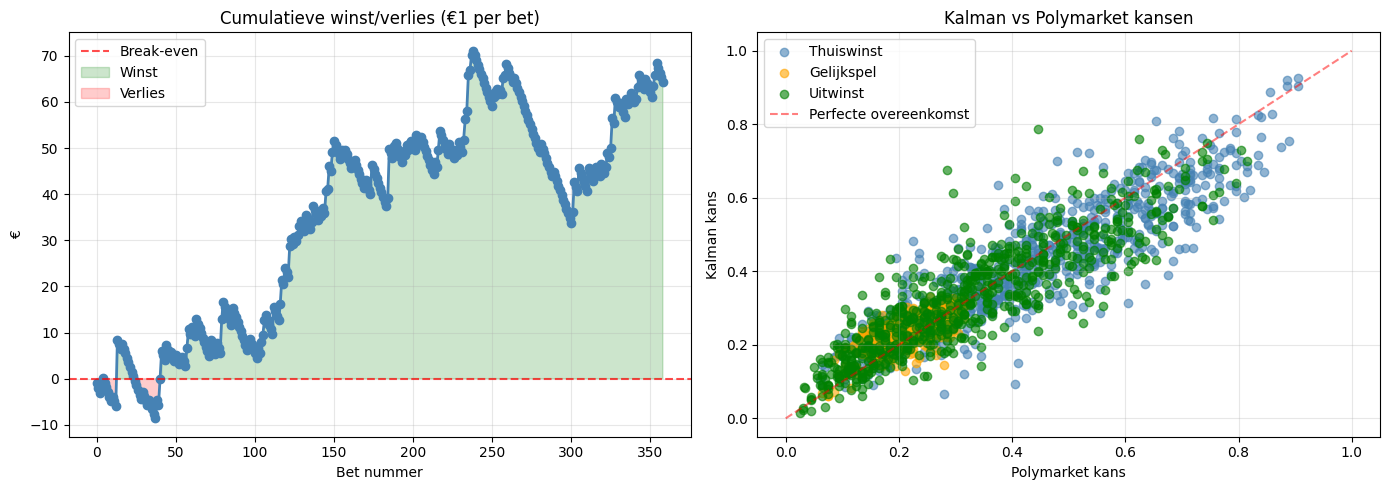

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulatieve winst
axes[0].plot(range(len(results_df)), results_df['cumulative'], marker='o', linewidth=2, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7, label='Break-even')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] >= 0, alpha=0.2, color='green', label='Winst')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] < 0, alpha=0.2, color='red', label='Verlies')
axes[0].set_title('Cumulatieve winst/verlies (€1 per bet)')
axes[0].set_xlabel('Bet nummer')
axes[0].set_ylabel('€')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kansen vergelijking: Kalman vs Polymarket
ax = axes[1]
x = range(len(sim))
ax.scatter(sim['prob_home'], sim['kalman_prob_home'], alpha=0.6, label='Thuiswinst', color='steelblue')
ax.scatter(sim['prob_draw'], sim['kalman_prob_draw'], alpha=0.6, label='Gelijkspel', color='orange')
ax.scatter(sim['prob_away'], sim['kalman_prob_away'], alpha=0.6, label='Uitwinst', color='green')
ax.plot([0,1],[0,1], 'r--', alpha=0.5, label='Perfecte overeenkomst')
ax.set_xlabel('Polymarket kans')
ax.set_ylabel('Kalman kans')
ax.set_title('Kalman vs Polymarket kansen')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_betting_simulatie.png', dpi=150)
plt.show()

## Stap 7 — Vergelijking Kalman vs Polymarket accuracy

In [39]:
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

# Voorspelling Kalman: hoogste kans
sim['kalman_pred'] = sim[['kalman_prob_home','kalman_prob_draw','kalman_prob_away']].idxmax(axis=1)
sim['kalman_pred'] = sim['kalman_pred'].map({
    'kalman_prob_home': 'H',
    'kalman_prob_draw': 'D',
    'kalman_prob_away': 'A'
})

# Voorspelling Polymarket: hoogste kans
sim['poly_pred'] = sim[['prob_home','prob_draw','prob_away']].idxmax(axis=1)
sim['poly_pred'] = sim['poly_pred'].map({
    'prob_home': 'H',
    'prob_draw': 'D',
    'prob_away': 'A'
})

print('=== ACCURACY ===')
print(f'Kalman:     {accuracy_score(sim["result"], sim["kalman_pred"]):.3f}')
print(f'Polymarket: {accuracy_score(sim["result"], sim["poly_pred"]):.3f}')

print('\n=== F1 MACRO ===')
print(f'Kalman:     {f1_score(sim["result"], sim["kalman_pred"], average="macro"):.3f}')
print(f'Polymarket: {f1_score(sim["result"], sim["poly_pred"], average="macro"):.3f}')

print('\n=== BRIER SCORE (lager = beter gekalibreerd) ===')
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (sim['result'] == outcome).astype(int)
    brier_k = brier_score_loss(actual_bin, sim[f'kalman_prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    brier_p = brier_score_loss(actual_bin, sim[f'prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    print(f'{label:8s} — Kalman: {brier_k:.3f}  Polymarket: {brier_p:.3f}')

=== ACCURACY ===
Kalman:     0.522
Polymarket: 0.524

=== F1 MACRO ===
Kalman:     0.397
Polymarket: 0.395

=== BRIER SCORE (lager = beter gekalibreerd) ===
Thuis    — Kalman: 0.213  Polymarket: 0.212
Gelijk   — Kalman: 0.192  Polymarket: 0.191
Uit      — Kalman: 0.193  Polymarket: 0.192


In [40]:
# ── CHECK 1: DATA LEAKAGE ────────────────────────────────────────────────────
print('=== LEAKAGE CHECK ===')
print('Kalman gebruikt pre-match state (voor de update) dus geen directe leakage.')
print('Check: correlatie tussen Kalman xG pred en werkelijke goals:')
corr_h = merged['kalman_xg_pred_home'].corr(merged['home_goals'].astype(float))
corr_a = merged['kalman_xg_pred_away'].corr(merged['away_goals'].astype(float))
print(f'Correlatie pred home xG vs werkelijke goals: {corr_h:.3f}')
print(f'Correlatie pred away xG vs werkelijke goals: {corr_a:.3f}')
print('(>0.6 = mogelijk leakage, ~0.2-0.4 = normaal voor goede voorspeller)')

# ── CHECK 2: VERSCHILLENDE DREMPELS ─────────────────────────────────────────
print('\n=== ROI BIJ VERSCHILLENDE DREMPELS ===')
sim_test = sim.copy()
for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    winst = 0
    bets  = 0
    for _, row in sim_test.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row['prob_home'],
            'D': row['kalman_prob_draw'] - row['prob_draw'],
            'A': row['kalman_prob_away'] - row['prob_away'],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= drempel:
            bets += 1
            poly_prob = row[f'prob_{"home" if best=="H" else "draw" if best=="D" else "away"}']
            odds = 1 / poly_prob
            winst += (odds - 1) if row['result'] == best else -1
    roi = winst/bets*100 if bets > 0 else 0
    print(f'Drempel {drempel:.2f} → {bets:3d} bets | ROI: {roi:+.1f}%')

# ── CHECK 3: RANDOM BASELINE ─────────────────────────────────────────────────
print('\n=== RANDOM BASELINE (1000x simulatie) ===')
import random
random.seed(42)
random_rois = []
for _ in range(1000):
    winst = 0
    for _, row in sim_test.iterrows():
        bet = random.choice(['H','D','A'])
        poly_prob = row[f'prob_{"home" if bet=="H" else "draw" if bet=="D" else "away"}']
        odds = 1 / poly_prob
        winst += (odds - 1) if row['result'] == bet else -1
    random_rois.append(winst/len(sim_test)*100)

model_roi = bankroll/bets_placed*100 if bets_placed > 0 else 0
p5  = np.percentile(random_rois, 2.5)
p95 = np.percentile(random_rois, 97.5)

print(f'Gemiddelde random ROI:  {np.mean(random_rois):+.1f}%')
print(f'Std random ROI:         {np.std(random_rois):.1f}%')
print(f'95% interval:           [{p5:+.1f}%, {p95:+.1f}%]')
print(f'Jouw model ROI:         {model_roi:+.1f}%')
print()
if p5 < model_roi < p95:
    print('⚠️  ROI valt BINNEN random interval — niet statistisch significant bij deze steekproef')
else:
    print('✅ ROI valt BUITEN random interval — statistisch significant op 95% niveau')

=== LEAKAGE CHECK ===
Kalman gebruikt pre-match state (voor de update) dus geen directe leakage.
Check: correlatie tussen Kalman xG pred en werkelijke goals:
Correlatie pred home xG vs werkelijke goals: 0.326
Correlatie pred away xG vs werkelijke goals: 0.323
(>0.6 = mogelijk leakage, ~0.2-0.4 = normaal voor goede voorspeller)

=== ROI BIJ VERSCHILLENDE DREMPELS ===
Drempel 0.00 → 690 bets | ROI: +12.5%
Drempel 0.02 → 593 bets | ROI: +13.3%
Drempel 0.05 → 372 bets | ROI: +16.6%
Drempel 0.08 → 215 bets | ROI: +5.7%
Drempel 0.10 → 142 bets | ROI: +23.8%
Drempel 0.15 →  47 bets | ROI: +16.5%
Drempel 0.20 →  14 bets | ROI: +43.5%

=== RANDOM BASELINE (1000x simulatie) ===
Gemiddelde random ROI:  +1.3%
Std random ROI:         6.1%
95% interval:           [-9.9%, +13.5%]
Jouw model ROI:         +16.6%

✅ ROI valt BUITEN random interval — statistisch significant op 95% niveau
